#라이브러리 설치

langchain

모델에 계속 외부 데이터 연결
- pdf 데이터
- 전에 학습한 데이터 등 ..

실질적으로 ChatGPT는 기존에 train한 정보에 대해서만 말하는건데 langchain을 통해서 '내가 가지고 있는 정보'를 넣어서 활용

In [13]:
%%capture
!pip install langchain openai python-dotenv
!pip install langchain_community

In [3]:
import os
from getpass import getpass
from dotenv import load_dotenv

In [4]:
# API 키를 안전하게 입력받기
api_key = getpass("OpenAI API 키를 입력하세요: ")
os.environ["OPENAI_API_KEY"] = api_key

OpenAI API 키를 입력하세요: ··········


In [5]:
# 라이브러리 임포트
from langchain.llms import OpenAI
from langchain.chat_models import ChatOpenAI
from langchain.schema import HumanMessage, SystemMessage, AIMessage
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain, SimpleSequentialChain, ConversationChain
from langchain.memory import ConversationBufferMemory

print("설정 완료!")

설정 완료!


basic llm

In [10]:
llm = OpenAI(temperature=0.5) #temperature 창의성을 얼마나 발휘할지

In [11]:
response = llm("LLM에서 langchain이 뭐야?")

In [12]:
print(response)



LLM은 Language Model로, 언어 모델을 의미합니다. 언어 모델은 자연어 처리 분야에서 사용되는 통계적 모델로, 문장이나 단어의 시퀀스를 예측하는 데 사용됩니다. 이 중에서 langchain은 언어 모델의 한 종류로, 여러 언어를 연결하여 다양한 언어를 처리할 수 있는 모델을 말합니다. 예를 들어, 영어와 한국어를 모두 포함하는 langchain 모델은 영어 문장을 입력하면 한국어로 번역하고, 한국어 문장을 입력하면 영어로 번역하는 등 다양한 언어 간 변환을 가능하게 합니다. 


------

# 채팅모델 활용하기

In [17]:
chat = ChatOpenAI(temperature=0.7, model = 'gpt-3.5-turbo') #temperature -> 창의성 얼마나 발휘하냐

In [15]:
messages = [
    SystemMessage(content = "당신은 파이썬 프로그래밍에 특화된 어시스턴트입니다"),
    HumanMessage(content = "문자열이 회문인지 확인하는 파이썬 함수를 작성해줘")
]

In [18]:
response = chat(messages)

<ipython-input-18-4280984bd2a8>:1: LangChainDeprecationWarning: The method `BaseChatModel.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  response = chat(messages)


In [19]:
print(response.content)

다음은 주어진 문자열이 회문인지 확인하는 함수의 예시입니다.

```python
def is_palindrome(s):
    s = s.lower() # 대소문자 구분을 없애기 위해 모두 소문자로 변환
    s = ''.join(e for e in s if e.isalnum()) # 영문자와 숫자만을 남기고 모든 공백 및 특수문자 제거
    return s == s[::-1]

# 함수 테스트
print(is_palindrome("A man, a plan, a canal, Panama"))  # True
print(is_palindrome("racecar"))  # True
print(is_palindrome("hello"))  # False
```

이 함수는 대소문자를 구분하지 않고, 영문자와 숫자만을 고려하여 주어진 문자열이 회문인지를 확인합니다.


-----

In [30]:
from re import template
template = "당신은 새로운 회사를 위한 이름을 제안하는 컨설턴트 입니다.{product}를 만드는 회사를 위한 좋은 이름 5개를 추천해주세요"

In [31]:
    prompt = PromptTemplate(
        input_variables=["product"],  # 템플릿에서 사용할 변수 목록
        template=template,            # 템플릿 문자열
    )

In [32]:
llm = OpenAI(temperature=0.5) #temperature 창의성을 얼마나 발휘할지

** lang chain : 언어를 체인으로 연결 **

In [33]:
# 두개 연결
chain = LLMChain(llm= llm, prompt=prompt)

In [34]:
response = chain.run("친환경 물병") # 친환경물병의 회사에 맞는 좋은 이름 추천

In [35]:
print(response)

.

1. "EcoBottle" - 친환경적인 이미지와 함께 물병을 제공하는 회사를 나타내는 이름입니다.
2. "GreenHydrate" - 녹색의 이미지와 함께 수분 보충을 위한 물병을 제공하는 회사를 나타내는 이름입니다.
3. "PureCycle" - 순환적인 생태계를 존중하며 물병을 제공하는 회사를 나타내는 이름입니다.
4. "EcoQuench" - 친환경적인 방식으로 갈증을 해소하는 물병을 제공하는 회사를 나타내는 이름입니다.
5. "SustainaBottle" - 지속가능한 방식으로 물병을 제공하는 회사를 나타내는 이름입니다.


------

- 이번에는 language model 끼리 대화

In [41]:
first_prompt = PromptTemplate(
        input_variables=["topic"],  # 템플릿에서 사용할 변수 목록
        template="{topic} 애플리케이션에 대한 한 문자 아이디어를 생성해주세요",            # 템플릿 문자열
    )

In [42]:
second_prompt = PromptTemplate(
        input_variables=["idea"],  # 템플릿에서 사용할 변수 목록
        template="다음 애플리케이션 아이디어를 위한 세 가지 핵심 기능을 제안해주세요:{idea}",            # 템플릿 문자열
    )

In [43]:
llm = ChatOpenAI(temperature=0.5)

chain_one = LLMChain(llm = llm, prompt=first_prompt)
chain_two = LLMChain(llm = llm, prompt=second_prompt)

In [44]:
over_chain = SimpleSequentialChain(chains=[chain_one, chain_two], verbose=True)

In [45]:
response = over_chain.run("생산성")
print(response)



> Entering new SimpleSequentialChain chain...
"작업 일정을 자동으로 관리해주는 생산성 앱 'TaskMaster'! 각 일정에 맞는 할 일 리스트를 생성하고, 작업 완료 시간을 기록하여 효율적인 업무 관리를 도와줍니다."
1. 스마트 일정 생성 기능: TaskMaster 앱은 사용자의 일정을 자동으로 분석하여 각 일정에 맞는 할 일 리스트를 생성해주는 기능을 제공합니다. 사용자는 간단히 일정을 입력하면 앱이 해당 일정에 필요한 작업들을 자동으로 할 일 리스트로 생성해줍니다.

2. 작업 완료 시간 기록 기능: 사용자가 각 작업을 완료할 때마다 앱을 통해 작업 완료 시간을 기록할 수 있습니다. 이를 통해 사용자는 자신의 작업 속도와 시간을 효율적으로 파악할 수 있고, 더 나은 업무 관리를 할 수 있습니다.

3. 통계 및 분석 기능: TaskMaster 앱은 사용자의 작업 패턴을 분석하여 통계 및 분석 기능을 제공합니다. 사용자는 자신의 작업 습관을 파악하고 개선할 수 있는 정보를 얻을 수 있으며, 더욱 효율적으로 작업 일정을 관리할 수 있습니다.

> Finished chain.
1. 스마트 일정 생성 기능: TaskMaster 앱은 사용자의 일정을 자동으로 분석하여 각 일정에 맞는 할 일 리스트를 생성해주는 기능을 제공합니다. 사용자는 간단히 일정을 입력하면 앱이 해당 일정에 필요한 작업들을 자동으로 할 일 리스트로 생성해줍니다.

2. 작업 완료 시간 기록 기능: 사용자가 각 작업을 완료할 때마다 앱을 통해 작업 완료 시간을 기록할 수 있습니다. 이를 통해 사용자는 자신의 작업 속도와 시간을 효율적으로 파악할 수 있고, 더 나은 업무 관리를 할 수 있습니다.

3. 통계 및 분석 기능: TaskMaster 앱은 사용자의 작업 패턴을 분석하여 통계 및 분석 기능을 제공합니다. 사용자는 자신의 작업 습관을 파악하고 개선할 수 있는 정보를 얻을 수 있으며, 더욱 효율적으로 작업 일정을 관리할 수 있습니다.


# 대화에 메모리기능 사용하기

In [52]:
llm = ChatOpenAI(temperature=0.5)

In [53]:
conversation = ConversationChain(
    llm=llm,
    memory = ConversationBufferMemory() ,# 대화 내용을 저장할 메모리 추가
    verbose = True
)

In [54]:
reponse1 = conversation.predict(input="제 이름은 선우이고 LangChain에 대해 배우고 있습니다.")
print(reponse1)



> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:

Human: 제 이름은 선우이고 LangChain에 대해 배우고 있습니다.
AI:

> Finished chain.
안녕하세요, 선우님! LangChain은 언어 간 상호 작용을 위한 블록체인 기술을 사용하는 플랫폼입니다. 이 플랫폼은 블록체인 기술을 활용하여 다양한 언어를 사용하는 사용자들 간의 의사 소통을 원활하게 돕는 것을 목표로 합니다. LangChain은 사용자들이 언어 장벽을 극복하고 쉽게 소통할 수 있도록 도와줍니다. 어떤 정보가 필요하신가요?


In [55]:
reponse2 = conversation.predict(input="내 이름이 무엇이고 뭐에 대해 배우고 있냐?")
print(reponse2)



> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:
Human: 제 이름은 선우이고 LangChain에 대해 배우고 있습니다.
AI: 안녕하세요, 선우님! LangChain은 언어 간 상호 작용을 위한 블록체인 기술을 사용하는 플랫폼입니다. 이 플랫폼은 블록체인 기술을 활용하여 다양한 언어를 사용하는 사용자들 간의 의사 소통을 원활하게 돕는 것을 목표로 합니다. LangChain은 사용자들이 언어 장벽을 극복하고 쉽게 소통할 수 있도록 도와줍니다. 어떤 정보가 필요하신가요?
Human: 내 이름이 무엇이고 뭐에 대해 배우고 있냐?
AI:

> Finished chain.
죄송합니다, 제가 당신의 이름을 알 수 있는 방법이 없습니다. 그러나 당신이 LangChain에 대해 배우고 있다고 말씀하셨습니다. LangChain은 언어 간 상호 작용을 위한 블록체인 기술을 사용하는 플랫폼입니다. 이 플랫폼은 사용자들이 언어 장벽을 극복하고 쉽게 소통할 수 있도록 돕는 것을 목표로 합니다. 어떤 정보가 더 필요하신가요?


-------

In [56]:
# 간단한 애플리케이션 예제: 문서 요약기
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain
from langchain.chat_models import ChatOpenAI

In [58]:
def document_summarizer():
    """
    입력된 텍스트를 요약하는 간단한 애플리케이션 예제
    """
    print("\n=== 문서 요약기 애플리케이션 ===")

    # 요약을 위한 프롬프트 템플릿 정의
    summarizer_template = """
    다음 텍스트를 세 문장으로 요약해주세요:

    텍스트: {text}

    한글 요약:
    """

    summarizer_prompt = PromptTemplate(
        input_variables=["text"],
        template=summarizer_template
    )

    # ChatGPT 모델을 사용하는 요약 체인 생성
    llm = ChatOpenAI(temperature=0.5, model="gpt-3.5-turbo")
    summarizer_chain = LLMChain(llm=llm, prompt=summarizer_prompt)

    # 사용자로부터 텍스트 입력 받기
    print("요약할 텍스트를 입력하세요 (여러 줄 입력 가능, 입력을 마치려면 '요약하기'를 입력하세요):")

    user_input_lines = []
    while True:
        line = input()
        if line.strip().lower() == '요약하기':
            break
        user_input_lines.append(line)

    user_text = "\n".join(user_input_lines)

    if not user_text.strip():
        print("텍스트가 입력되지 않았습니다.")
        return

    # 텍스트 요약하기
    print("\n요약 중...")
    summary = summarizer_chain.run(user_text)

    print("\n===== 요약 결과 =====")
    print(summary)

# 요약기 실행
document_summarizer()



=== 문서 요약기 애플리케이션 ===
요약할 텍스트를 입력하세요 (여러 줄 입력 가능, 입력을 마치려면 '요약하기'를 입력하세요):
수 휘성(본명 최휘성)이 43세 나이로 사망했다.  10일 경찰과 소속사 등에 따르면 휘성은 서울 광진구의 한 아파트에서 이날 오후 6시 29분쯤 심정지 상태로 발견됐다.  소방 당국 등은 휘성의 모친으로부터 신고를 받고 출동한 것으로 전해졌다.  경찰은 현재까지 외부 침입 흔적 등 범죄 혐의점은 확인되지 않은 것으로 보고 유서 여부와 구체적인 사망 경위 등을 수사 중이다.  이날 휘성 소속사 타조엔터테인먼트는 “금일 소속 아티스트인 휘성 님이 우리 곁을 떠났다”며 “고인은 서울 자택에서 심정지 상태로 발견돼 사망 판정을 받았다”고 밝혔다.


요약하기

요약 중...

===== 요약 결과 =====
가수 휘성이 43세에 서울 광진구 아파트에서 심정지 상태로 발견되어 사망했다. 경찰은 외부 침입 흔적 등 범죄 혐의가 없는 것으로 확인했고, 유서 여부와 사망 경위를 조사 중이다. 휘성 소속사는 휘성이 자택에서 사망했다고 밝혔다.


In [60]:
# 종합 애플리케이션: 다국어 대화형 지식 비서
from langchain.chat_models import ChatOpenAI
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory
from langchain.prompts import ChatPromptTemplate, MessagesPlaceholder, HumanMessagePromptTemplate, SystemMessagePromptTemplate

def multilingual_assistant():
    """
    여러 언어를 지원하는 대화형 지식 비서 애플리케이션
    """
    print("\n=== 다국어 대화형 지식 비서 ===")
    print("이 비서는 한국어, 영어 등 여러 언어로 대화하고 답변할 수 있습니다.")
    print("대화를 종료하려면 '종료'를 입력하세요.\n")

    # 대화 템플릿 생성하기
    prompt = ChatPromptTemplate.from_messages([
        SystemMessagePromptTemplate.from_template(
            """당신은 친절하고 지식이 풍부한 AI 비서입니다.
            사용자가 어떤 언어로 질문하든 같은 언어로 답변해 주세요.
            답변은 명확하고 유용하며 친절해야 합니다.
            모르는 질문에는 솔직하게 모른다고 말하세요."""
        ),
        MessagesPlaceholder(variable_name="history"),
        HumanMessagePromptTemplate.from_template("{input}")
    ])

    # 대화 모델 초기화
    llm = ChatOpenAI(temperature=0.7, model="gpt-3.5-turbo")

    # 메모리 및 대화 체인 설정
    memory = ConversationBufferMemory(return_messages=True)
    conversation = ConversationChain(
        memory=memory,
        prompt=prompt,
        llm=llm
    )

    # 대화 루프
    while True:
        user_input = input("질문: ")

        if user_input.lower() in ['종료', 'exit', 'quit']:
            print("\n대화를 종료합니다. 감사합니다!")
            break

        response = conversation.predict(input=user_input)
        print(f"\n비서: {response}\n")


In [61]:
# 다국어 비서 실행
multilingual_assistant()


=== 다국어 대화형 지식 비서 ===
이 비서는 한국어, 영어 등 여러 언어로 대화하고 답변할 수 있습니다.
대화를 종료하려면 '종료'를 입력하세요.

질문: 밥 먹었어?

비서: 아니요, 제가 밥을 먹을 필요는 없습니다. 하지만 궁금하시다면 제가 밥을 먹을 수 있는 능력은 없습니다. 또한, 제가 식사를 할 수 있는 능력은 없습니다.

질문: Pa maʼ gudócabe gueta la?

비서: 죄송합니다. 이해하지 못했습니다. 다른 질문이 있으시면 도와드리겠습니다.

질문: Byl fotbal zábavný?

비서: 네, 축구는 많은 사람들에게 재미있는 스포츠입니다. 경기의 긴장감과 전략, 팀워크, 그리고 승부욕이 많은 이들을 끌어들이는 이유 중 하나입니다. 또한 축구는 전 세계적으로 인기 있는 스포츠로 많은 사람들이 즐기고 응원합니다.

질문: Pa maʼ gudócabe gueta la?

비서: Lo siento, no entendí la pregunta. ¿Puedes intentar formularla de otra manera o hacerme otra pregunta? Estoy aquí para ayudarte.

질문: Pa maʼ gudócabe gueta la?

비서: Desculpe, mas não compreendi a pergunta. Poderia reformulá-la ou fazer outra pergunta? Estou aqui para ajudar.

질문: 한국어로 대답해야하는거 아냐?

비서: 네, 죄송합니다. 한국어로 대답해야 했는데 실수했습니다. 다시 한 번 질문을 해주시면 정확한 답변을 드리겠습니다. 혼란을 드려 죄송합니다.

질문: Pa maʼ gudócabe gueta la?

비서: 죄송합니다. 그 질문에 대해서는 아직도 이해하지 못했습니다. 다른 질문이 있으시면 도와드리겠습니다.

질문: 종료

대화를 종료합니다. 감사합니다!


아래와 같이 시스템이 작동됨

- pdf 파일을 로드 → 텍스트로 변환

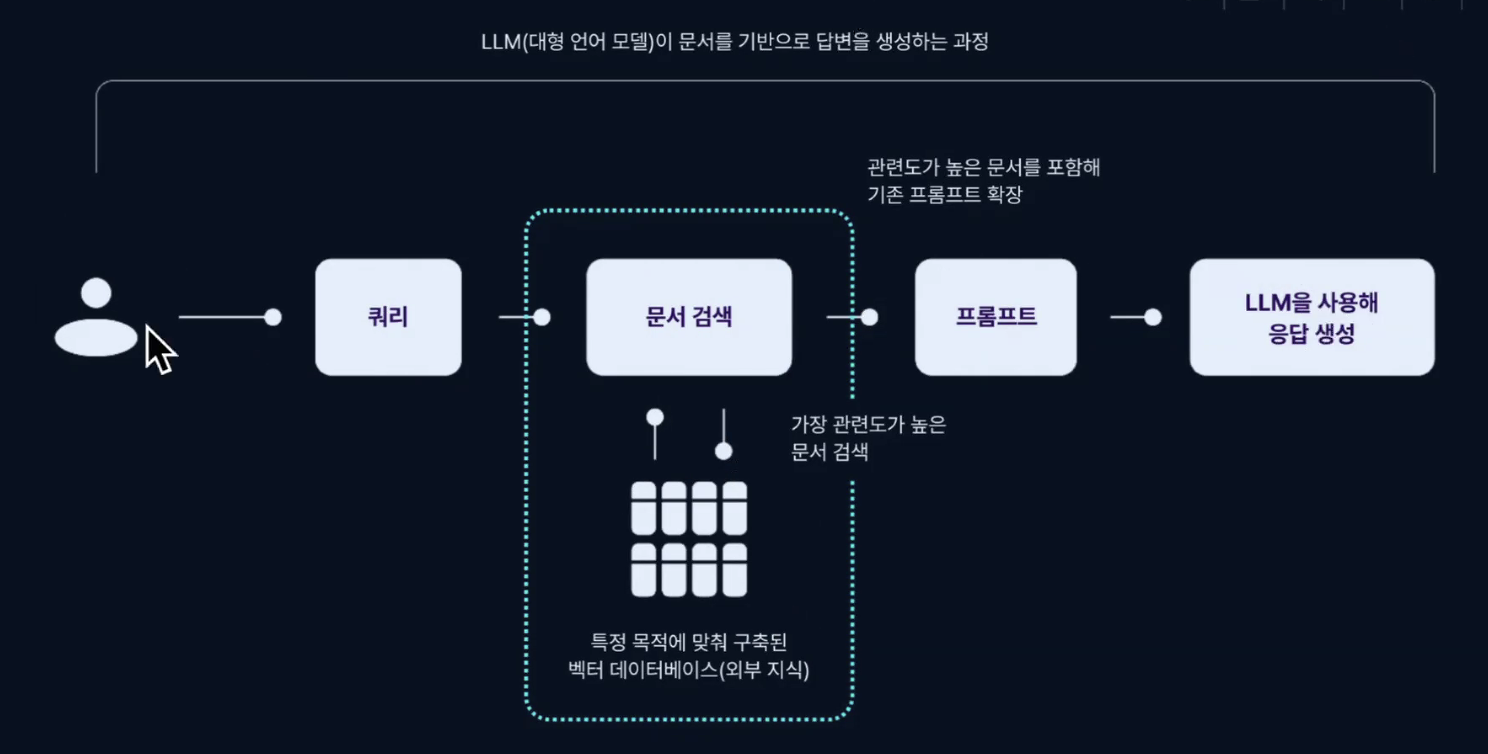